# **EXPLORACIÓN DE DATOS (EDA) — BANCO ATLAS**
- Base de datos: df_original_proyeccion_260511

## **Objetivos**:
- Generen resúmenes estadísticos (media, mediana, desviación estándar, etc.).
- Identificación completa de valores faltantes y uso de técnicas adecuadas para gestionarlos, con una justificación breve de las decisiones tomadas.
- Creen visualizaciones iniciales (histogramas, gráficos de dispersión, diagramas de caja, etc.) para identificar tendencias o anomalías.
- Identificación de outliers en las variables relevantes, con una estrategia de tratamiento aplicada y justificación.
- Detecten correlaciones entre variables.
- Análisis de la distribución de la variable objetivo para identificar desbalance y aplicar, si es necesario, técnicas de balanceo con justificación adecuada.
- Resumen claro y conciso que aborde los hallazgos principales de la EDA y las decisiones tomadas, indicando una visión general del estado de los datos para el modelado.

# Instalación librerias y bibliotecas

In [1]:
! pip install sweetviz


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sweetviz as sv
import sys
sys.prefix

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'c:\\Users\\ADMIN\\AppData\\Local\\Programs\\Python\\Python313'

In [3]:
'''
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')  
sns.set_palette("husl")          

# Configuración de pandas para visualización completa
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimales
'''    

'\n# Configuración de visualización\nplt.style.use(\'seaborn-v0_8-darkgrid\')  \nsns.set_palette("husl")          \n\n# Configuración de pandas para visualización completa\npd.set_option(\'display.max_columns\', None)  # Mostrar todas las columnas\npd.set_option(\'display.max_rows\', 100)      # Mostrar hasta 100 filas\npd.set_option(\'display.float_format\', \'{:.2f}\'.format)  # 2 decimales\n'

# Cargar el dataset

In [4]:
df=pd.read_csv("../../data/df_original_proyeccion_INE_2026-2036_260511.csv")
df


,Periodo,Menor 34,35-44,45-54,55-64,65 o más,Total_pobl,Crecimiento_pobl,Edad_media,Ind_envejecer,Saldo_vegetativo,Saldo_migratorio,Tasa_mortalidad,Tasa_natalidad
0,2026,1.755155e+07,6.593651e+06,8.133932e+06,7.168323e+06,1.046280e+07,4.991228e+07,"11,866794","44,711298","153,941008","-2,534351","14,401145","9,276262","6,741911"
1,2027,1.772376e+07,6.568482e+06,8.162352e+06,7.321511e+06,1.072996e+07,5.050809e+07,"10,397509","44,888040","159,641397","-2,456478","12,853987","9,255500","6,799022"
2,2028,1.784642e+07,6.565151e+06,8.147893e+06,7.470007e+06,1.100448e+07,5.103598e+07,"8,884314","45,075277","165,553194","-2,391228","11,275542","9,247679","6,856451"
3,2029,1.793544e+07,6.571732e+06,8.092160e+06,7.597356e+06,1.129269e+07,5.149140e+07,"7,482023","45,273068","171,747256","-2,344531","9,826554","9,258558","6,914027"
4,2030,1.799492e+07,6.572785e+06,7.994228e+06,7.708280e+06,1.160585e+07,5.187809e+07,"6,271706","45,479698","177,995952","-2,313756","8,585462","9,286330","6,972574"
5,2031,1.802391e+07,6.578049e+06,7.866698e+06,7.831687e+06,1.190210e+07,5.220447e+07,"5,282207","45,692629","184,398327","-2,295819","7,578026","9,329188","7,033369"
6,2032,1.802591e+07,6.588813e+06,7.713924e+06,7.954285e+06,1.219598e+07,5.248094e+07,"4,508795","45,908968","190,799344","-2,289001","6,797796","9,386697","7,097696"
7,2033,1.800168e+07,6.607934e+06,7.561500e+06,8.045919e+06,1.249904e+07,5.271810e+07,"3,928678","46,125685","197,213161","-2,291601","6,220279","9,457570","7,165969"
8,2034,1.796991e+07,6.618962e+06,7.412039e+06,8.132516e+06,1.279015e+07,5.292561e+07,"3,510998","46,339900","202,920685","-2,301535","5,812533","9,539604","7,238069"
9,2035,1.791712e+07,6.644629e+06,7.285432e+06,8.182162e+06,1.308038e+07,5.311175e+07,"3,222473","46,549073","207,875033","-2,316932","5,539405","9,630037","7,313105"


# Descripción del dataset:


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   Menor 34          11 non-null     float64
 2   35-44             11 non-null     float64
 3   45-54             11 non-null     float64
 4   55-64             11 non-null     float64
 5   65 o más          11 non-null     float64
 6   Total_pobl        11 non-null     float64
 7   Crecimiento_pobl  11 non-null     object 
 8   Edad_media        11 non-null     object 
 9   Ind_envejecer     11 non-null     object 
 10  Saldo_vegetativo  11 non-null     object 
 11  Saldo_migratorio  11 non-null     object 
 12  Tasa_mortalidad   11 non-null     object 
 13  Tasa_natalidad    11 non-null     object 
dtypes: float64(6), int64(1), object(7)
memory usage: 1.3+ KB


El conjunto contiene **10 registros y 15 columnas** 
Cada registro representa un año
las columnas representan los siguientes atributos:
- **[1-6]**: son rangos de edad y representa los millones de persona por franja de edad
-  **Total_pobl**:
- **Crecimiento_pobl**:
- **Edad_media**:
- **Ind_envejecimiento**: indice de envejecimiento
- **Saldo_vegetativo**: 
- **Saldo_migratorio**: 
- **Tasa_mortalidad**:
- **Tasa_natalidad**: 

Este dataset se armó manualmente con información extraido de la fuente externa del INE, se extrajeron solo las variables que se consideraron importantes dentro del marco de proyeccion poblacion para el sector bancario.



# Información general del dataset:
- Se observa que el dataser esta predominado por dos tipos de elementos: 1. float en las ccolumnas de rangos de edad y 2. object en el resto de columnas. Hay que corregirlo pues todas las variables son numericas.
- Hay que asegurarse que los types de las variables sea coherente con lo que representa cada columna, a simple vista es correcto.
- Maybe periodo ponerlo en int porque son los años de referencia mas no se hará operaciones con ellos.
- a simple vista no hay datos como Unknown o faltantes

## Correccion de types:

In [6]:
cols_a_fix = [
    'Crecimiento_pobl', 'Edad_media', 'Ind_envejecer', 
    'Saldo_vegetativo', 'Saldo_migratorio', 'Tasa_mortalidad', 'Tasa_natalidad']


for col in cols_a_fix:
    
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   Menor 34          11 non-null     float64
 2   35-44             11 non-null     float64
 3   45-54             11 non-null     float64
 4   55-64             11 non-null     float64
 5   65 o más          11 non-null     float64
 6   Total_pobl        11 non-null     float64
 7   Crecimiento_pobl  11 non-null     float64
 8   Edad_media        11 non-null     float64
 9   Ind_envejecer     11 non-null     float64
 10  Saldo_vegetativo  11 non-null     float64
 11  Saldo_migratorio  11 non-null     float64
 12  Tasa_mortalidad   11 non-null     float64
 13  Tasa_natalidad    11 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.3 KB


# Calidad de datos:

## Valores faltantes:

In [7]:
df.isnull().mean().sort_values(ascending=False)



Periodo             0.0
Menor 34            0.0
35-44               0.0
45-54               0.0
55-64               0.0
65 o más            0.0
Total_pobl          0.0
Crecimiento_pobl    0.0
Edad_media          0.0
Ind_envejecer       0.0
Saldo_vegetativo    0.0
Saldo_migratorio    0.0
Tasa_mortalidad     0.0
Tasa_natalidad      0.0
dtype: float64

Ole, no hay ningun null

## Filas duplicadas:


In [8]:
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados / len(df)) * 100:.2f}%")

Total de registros duplicados: 0
Porcentaje de duplicados: 0.00%


# Descripción estadística del dataset:

In [9]:
df.describe()

,Periodo,Menor 34,35-44,45-54,55-64,65 o más,Total_pobl,Crecimiento_pobl,Edad_media,Ind_envejecer,Saldo_vegetativo,Saldo_migratorio,Tasa_mortalidad,Tasa_natalidad
count,11.000000,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,2031.000000,1.789451e+07,6.599457e+06,7.776415e+06,7.783521e+06,1.190315e+07,5.195908e+07,6.216493,45.708612,184.029441,-2.352449,8.568942,9.399782,7.047333
std,3.316625,1.464952e+05,3.719590e+04,3.689484e+05,3.592551e+05,9.740821e+05,1.108913e+06,3.059665,0.686819,19.924200,0.078663,3.129586,0.168003,0.213292
min,2026.000000,1.755155e+07,6.565151e+06,7.170402e+06,7.168323e+06,1.046280e+07,4.991228e+07,3.025926,44.711298,153.941008,-2.534351,5.367634,9.247679,6.741911
25%,2028.500000,1.784770e+07,6.572258e+06,7.486769e+06,7.533682e+06,1.114858e+07,5.126369e+07,3.719838,45.174172,168.650225,-2.367879,6.016406,9.267410,6.885239
50%,2031.000000,1.793544e+07,6.588813e+06,7.866698e+06,7.831687e+06,1.190210e+07,5.220447e+07,5.282207,45.692629,184.398327,-2.316932,7.578026,9.329188,7.033369
75%,2033.500000,1.799830e+07,6.613448e+06,8.113046e+06,8.089218e+06,1.264459e+07,5.282185e+07,8.183169,46.232793,200.066923,-2.298677,10.551048,9.498587,7.202019
max,2036.000000,1.802591e+07,6.683842e+06,8.162352e+06,8.206682e+06,1.337123e+07,5.328317e+07,11.866794,46.751092,212.238496,-2.289001,14.401145,9.730181,7.388473


# Variables numéricas:

In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')
print(f"\n Variables numéricas a analizar: {numeric_cols}")


 Variables numéricas a analizar: ['Periodo', 'Menor 34', '35-44', '45-54', '55-64', '65 o más', 'Total_pobl', 'Crecimiento_pobl', 'Edad_media', 'Ind_envejecer', 'Saldo_vegetativo', 'Saldo_migratorio', 'Tasa_mortalidad', 'Tasa_natalidad']


In [11]:
stats_summary = pd.DataFrame({
    'Variable': numeric_cols,
    'Media': [df[col].mean() for col in numeric_cols],
    'Mediana': [df[col].median() for col in numeric_cols],
    'Moda': [df[col].mode()[0] if not df[col].mode().empty else np.nan for col in numeric_cols],
    'Desv_std': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Rango': [df[col].max() - df[col].min() for col in numeric_cols]})

print(f"\n RESUMEN ESTADÍSTICO:")
display(stats_summary)


 RESUMEN ESTADÍSTICO:


,Variable,Media,Mediana,Moda,Desv_std,Min,Max,Rango
0,Periodo,2.031000e+03,2.031000e+03,2.026000e+03,3.316625e+00,2.026000e+03,2.036000e+03,1.000000e+01
1,Menor 34,1.789451e+07,1.793544e+07,1.755155e+07,1.464952e+05,1.755155e+07,1.802591e+07,4.743581e+05
2,35-44,6.599457e+06,6.588813e+06,6.565151e+06,3.719590e+04,6.565151e+06,6.683842e+06,1.186909e+05
3,45-54,7.776415e+06,7.866698e+06,7.170402e+06,3.689484e+05,7.170402e+06,8.162352e+06,9.919500e+05
4,55-64,7.783521e+06,7.831687e+06,7.168323e+06,3.592551e+05,7.168323e+06,8.206682e+06,1.038359e+06
5,65 o más,1.190315e+07,1.190210e+07,1.046280e+07,9.740821e+05,1.046280e+07,1.337123e+07,2.908427e+06
6,Total_pobl,5.195908e+07,5.220447e+07,4.991228e+07,1.108913e+06,4.991228e+07,5.328317e+07,3.370892e+06
7,Crecimiento_pobl,6.216493e+00,5.282207e+00,3.025926e+00,3.059665e+00,3.025926e+00,1.186679e+01,8.840868e+00
8,Edad_media,4.570861e+01,4.569263e+01,4.471130e+01,6.868187e-01,4.471130e+01,4.675109e+01,2.039794e+00
9,Ind_envejecer,1.840294e+02,1.843983e+02,1.539410e+02,1.992420e+01,1.539410e+02,2.122385e+02,5.829749e+01


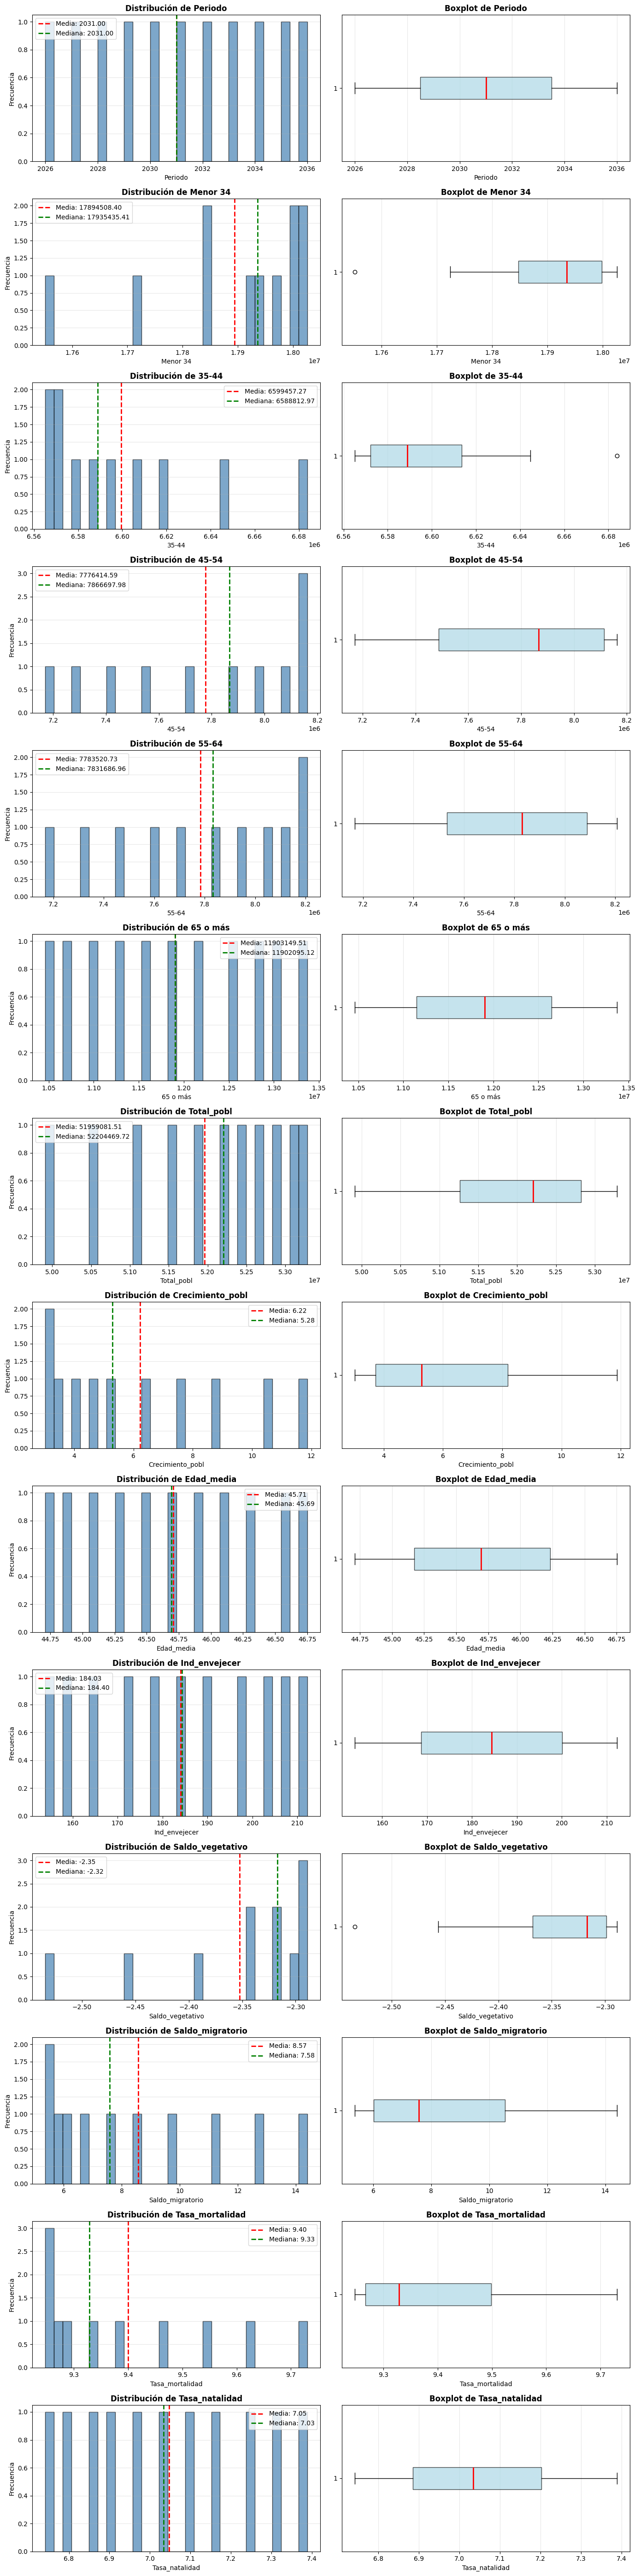

In [12]:
# 3. Visualización de distribuciones: histogramas + boxplots
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histograma con KDE (distribución suavizada)
    axes[i, 0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df[col].median():.2f}')
    axes[i, 0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Boxplot (detectar outliers)
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## EDA automàtic amb Sweetviz

In [13]:
'''
report = sv.analyze(df)
report.show_html('EDA_report.html')
'''

"\nreport = sv.analyze(df)\nreport.show_html('EDA_report.html')\n"

## Detección de outliers (método IQR — Rango Intercuartílico)


In [14]:
print(f"\n DETECCIÓN DE OUTLIERS (Método IQR):")

outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outliers_summary.append({
        'Variable': col,
        'N_outliers': n_outliers,
        'Porcentaje': pct_outliers,
        'Límite_inferior': lower_bound,
        'Límite_superior': upper_bound
    })

outliers_df = pd.DataFrame(outliers_summary).sort_values('N_outliers', ascending=False)
display(outliers_df)


 DETECCIÓN DE OUTLIERS (Método IQR):


,Variable,N_outliers,Porcentaje,Límite_inferior,Límite_superior
1,Menor 34,1,9.090909,1.762181e+07,1.822419e+07
2,35-44,1,9.090909,6.510474e+06,6.675232e+06
10,Saldo_vegetativo,1,9.090909,-2.471683e+00,-2.194873e+00
0,Periodo,0,0.000000,2.021000e+03,2.041000e+03
4,55-64,0,0.000000,6.700377e+06,8.922522e+06
3,45-54,0,0.000000,6.547354e+06,9.052461e+06
5,65 o más,0,0.000000,8.904574e+06,1.488860e+07
6,Total_pobl,0,0.000000,4.892644e+07,5.515910e+07
8,Edad_media,0,0.000000,4.358624e+01,4.782072e+01
7,Crecimiento_pobl,0,0.000000,-2.975158e+00,1.487816e+01


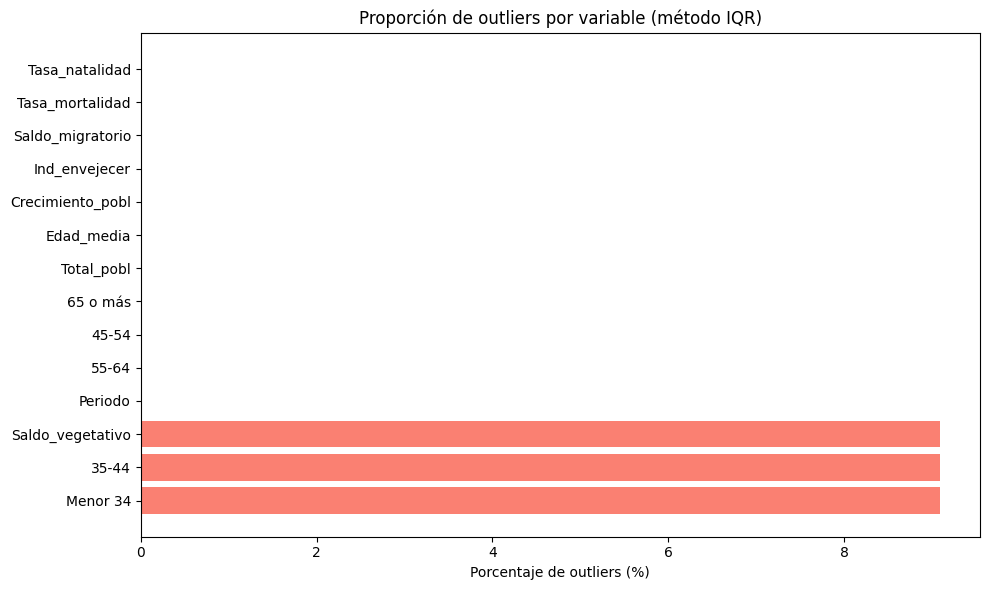

In [15]:
# Visualización de outliers por variable
plt.figure(figsize=(10, 6))
plt.barh(outliers_df['Variable'], outliers_df['Porcentaje'], color='salmon')
plt.xlabel('Porcentaje de outliers (%)')
plt.title('Proporción de outliers por variable (método IQR)')
plt.tight_layout()
plt.show()

# Correlacion

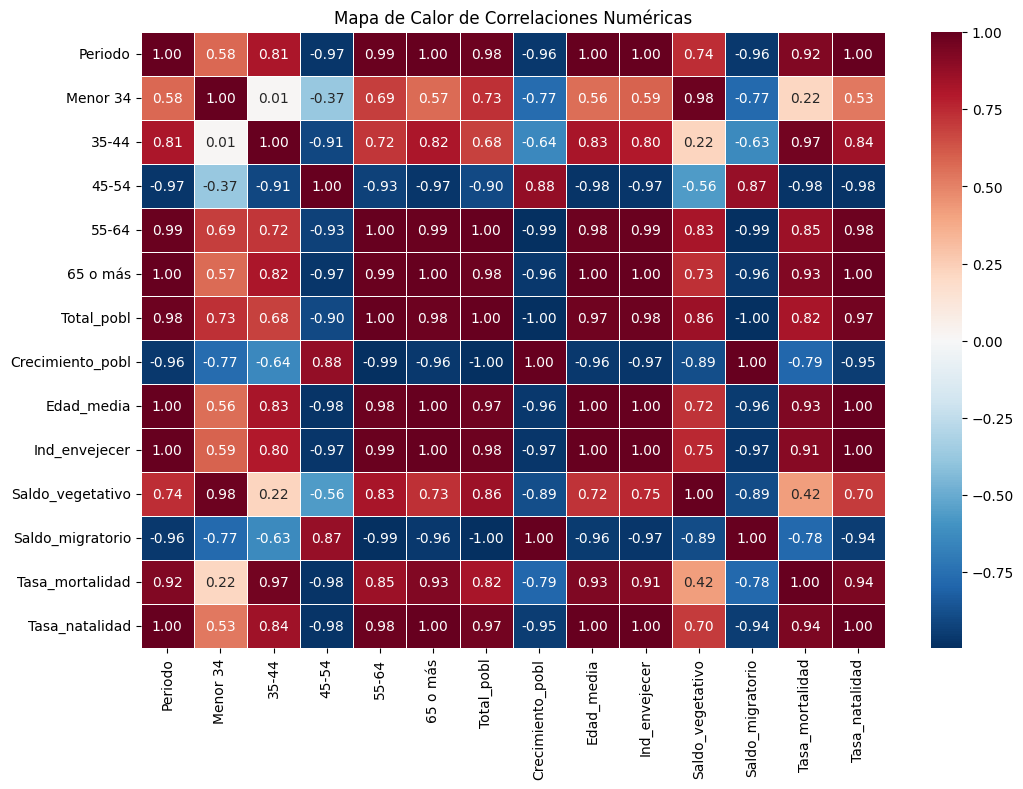

In [16]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()

## heatmap conclusion:
- Edad_media e Ind_envejecer (1.00): Tienen una correlación.
si la edad media sube, el índice de envejecimiento también. 
considerar quitar una de las dos porque aportan la misma información.

- Tasa_mortalidad y <=25 (-1.00): Hay una relación inversa. Esto sugiere un cambio generacional muy marcado

- Saldo_vegetativo. Es la que tiene colores más variados y no tan extremos (0.74, 0.78, 0.42).

A diferencia de las otras variables que parecen seguir una línea recta perfecta, el saldo vegetativo (nacimientos menos defunciones) tiene un comportamiento más complejo, no es tan predecible como el resto

Insight: Si tienes que predecir algo difícil, esta es la variable que le dará "sabor" al modelo porque .

# Analisis temporal:

## Tendencia poblacional por periodo

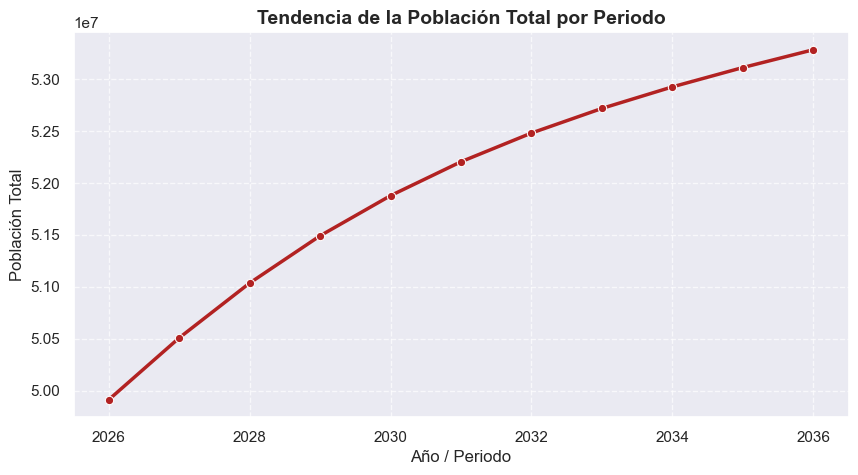

In [17]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Periodo', y='Total_pobl', marker='o', color='firebrick', linewidth=2.5)

plt.title('Tendencia de la Población Total por Periodo', fontsize=14, fontweight='bold')
plt.xlabel('Año / Periodo')
plt.ylabel('Población Total')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Tendencia poblacional (Natalidad vs Mortalidad)

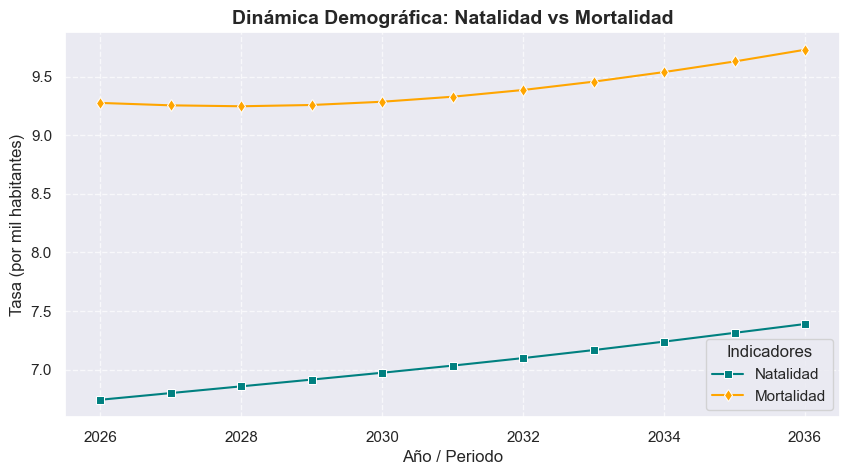

In [18]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Periodo', y='Tasa_natalidad', marker='s', label='Natalidad', color='teal')
sns.lineplot(data=df, x='Periodo', y='Tasa_mortalidad', marker='d', label='Mortalidad', color='orange')

plt.title('Dinámica Demográfica: Natalidad vs Mortalidad', fontsize=14, fontweight='bold')
plt.xlabel('Año / Periodo')
plt.ylabel('Tasa (por mil habitantes)')
plt.legend(title='Indicadores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Tendencia poblacional por saldo vegetativo

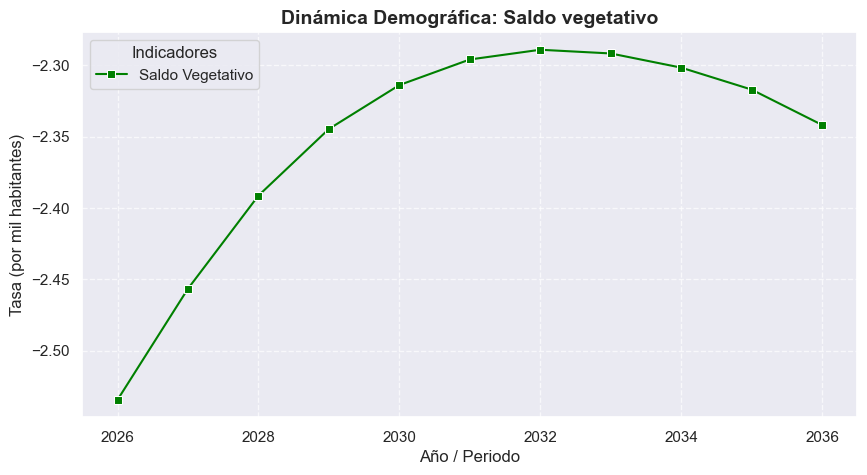

In [19]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='Periodo', y='Saldo_vegetativo', marker='s', label='Saldo Vegetativo', color='green')

plt.title('Dinámica Demográfica: Saldo vegetativo', fontsize=14, fontweight='bold')
plt.xlabel('Año / Periodo')
plt.ylabel('Tasa (por mil habitantes)')
plt.legend(title='Indicadores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Tendencia poblacional por saldo migratorio

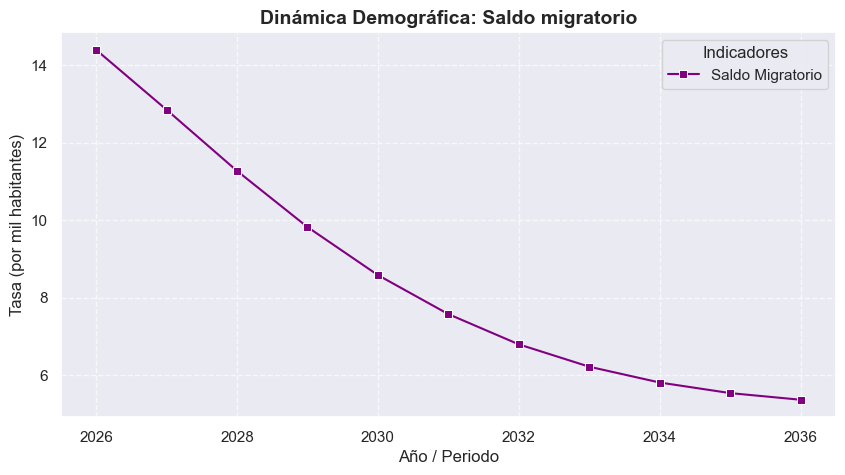

In [20]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='Periodo', y='Saldo_migratorio', marker='s', label='Saldo Migratorio', color='purple')

plt.title('Dinámica Demográfica: Saldo migratorio', fontsize=14, fontweight='bold')
plt.xlabel('Año / Periodo')
plt.ylabel('Tasa (por mil habitantes)')
plt.legend(title='Indicadores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
df

,Periodo,Menor 34,35-44,45-54,55-64,65 o más,Total_pobl,Crecimiento_pobl,Edad_media,Ind_envejecer,Saldo_vegetativo,Saldo_migratorio,Tasa_mortalidad,Tasa_natalidad
0,2026,1.755155e+07,6.593651e+06,8.133932e+06,7.168323e+06,1.046280e+07,4.991228e+07,11.866794,44.711298,153.941008,-2.534351,14.401145,9.276262,6.741911
1,2027,1.772376e+07,6.568482e+06,8.162352e+06,7.321511e+06,1.072996e+07,5.050809e+07,10.397509,44.888040,159.641397,-2.456478,12.853987,9.255500,6.799022
2,2028,1.784642e+07,6.565151e+06,8.147893e+06,7.470007e+06,1.100448e+07,5.103598e+07,8.884314,45.075277,165.553194,-2.391228,11.275542,9.247679,6.856451
3,2029,1.793544e+07,6.571732e+06,8.092160e+06,7.597356e+06,1.129269e+07,5.149140e+07,7.482023,45.273068,171.747256,-2.344531,9.826554,9.258558,6.914027
4,2030,1.799492e+07,6.572785e+06,7.994228e+06,7.708280e+06,1.160585e+07,5.187809e+07,6.271706,45.479698,177.995952,-2.313756,8.585462,9.286330,6.972574
5,2031,1.802391e+07,6.578049e+06,7.866698e+06,7.831687e+06,1.190210e+07,5.220447e+07,5.282207,45.692629,184.398327,-2.295819,7.578026,9.329188,7.033369
6,2032,1.802591e+07,6.588813e+06,7.713924e+06,7.954285e+06,1.219598e+07,5.248094e+07,4.508795,45.908968,190.799344,-2.289001,6.797796,9.386697,7.097696
7,2033,1.800168e+07,6.607934e+06,7.561500e+06,8.045919e+06,1.249904e+07,5.271810e+07,3.928678,46.125685,197.213161,-2.291601,6.220279,9.457570,7.165969
8,2034,1.796991e+07,6.618962e+06,7.412039e+06,8.132516e+06,1.279015e+07,5.292561e+07,3.510998,46.339900,202.920685,-2.301535,5.812533,9.539604,7.238069
9,2035,1.791712e+07,6.644629e+06,7.285432e+06,8.182162e+06,1.308038e+07,5.311175e+07,3.222473,46.549073,207.875033,-2.316932,5.539405,9.630037,7.313105


# Piramide poblacional:

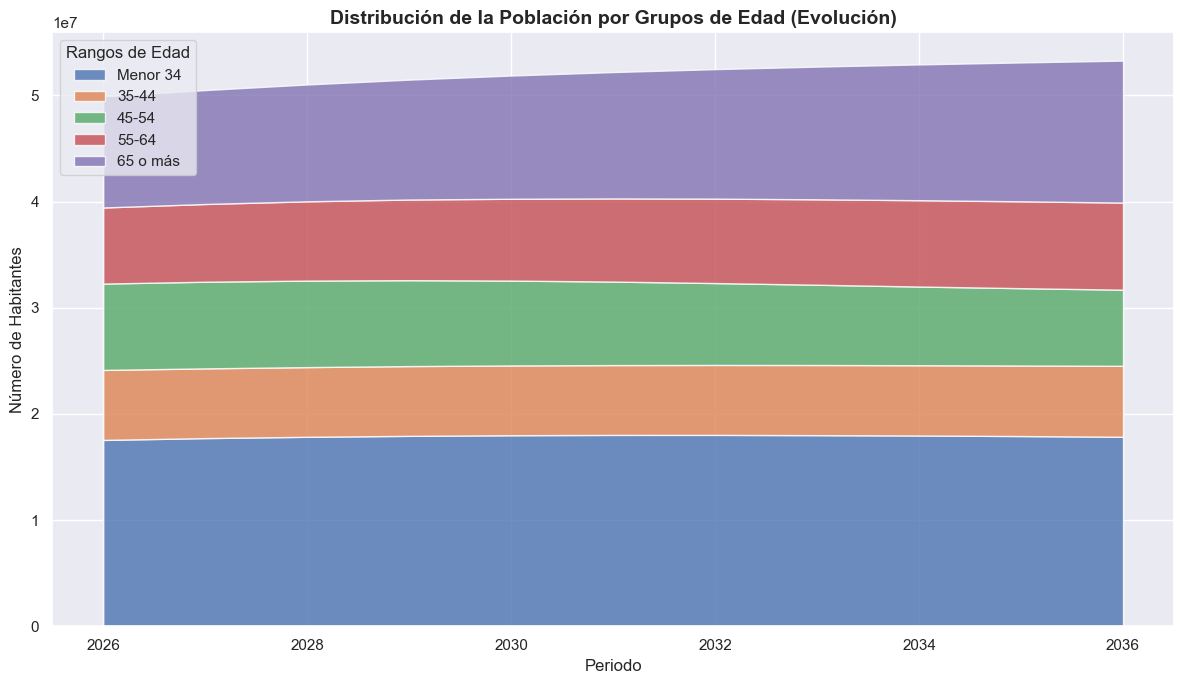

In [23]:
# Definimos los grupos de edad que identificamos en tu df
grupos_edad = ['Menor 34', '35-44', '45-54', '55-64', '65 o más']

# Creamos el gráfico de áreas
plt.figure(figsize=(12, 7))
plt.stackplot(df['Periodo'], 
              [df[grupo] for grupo in grupos_edad], 
              labels=grupos_edad, 
              alpha=0.8)

plt.title('Distribución de la Población por Grupos de Edad (Evolución)', fontsize=14, fontweight='bold')
plt.xlabel('Periodo')
plt.ylabel('Número de Habitantes')
plt.legend(loc='upper left', title="Rangos de Edad")
plt.tight_layout()
plt.show()

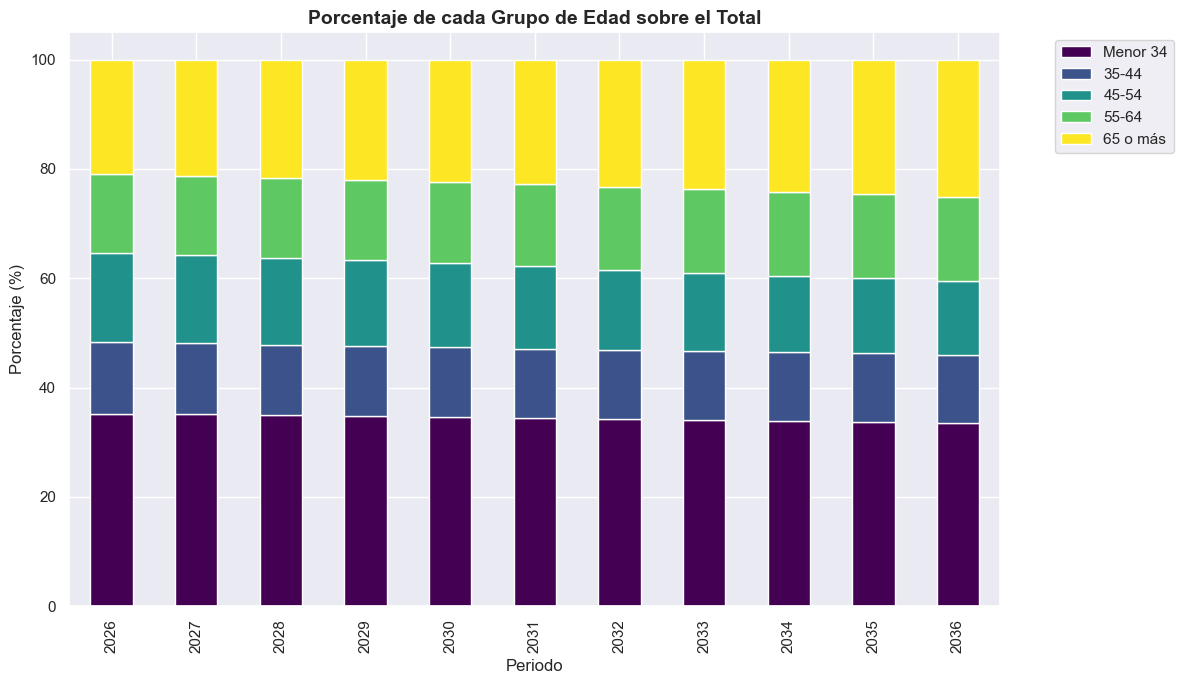

In [24]:
# Calculamos los porcentajes
df_perc = df[grupos_edad].div(df['Total_pobl'], axis=0) * 100
df_perc['Periodo'] = df['Periodo']

# Graficamos
df_perc.set_index('Periodo').plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Porcentaje de cada Grupo de Edad sobre el Total', fontsize=14, fontweight='bold')
plt.xlabel('Periodo')
plt.ylabel('Porcentaje (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

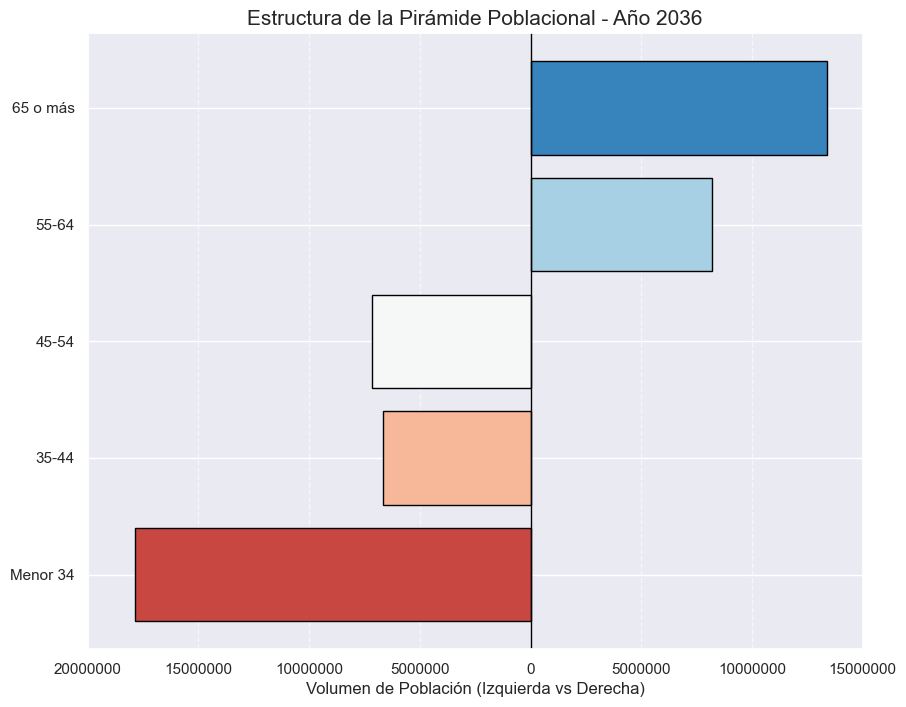

In [26]:
# 1. Seleccionamos un año para la foto fija (ejemplo: el último año disponible)
ultimo_periodo = df['Periodo'].max()
df_piramide = df[df['Periodo'] == ultimo_periodo].iloc[0]

# 2. Definimos los grupos y sus valores
grupos = ['Menor 34', '35-44', '45-54', '55-64', '65 o más']
valores = [df_piramide[g] for g in grupos]

# 3. Para que parezca una pirámide, dividimos los grupos "espejo"
# Nota: Como no tienes género, dividiremos los grupos para que se vea la estructura
y_pos = range(len(grupos))

plt.figure(figsize=(10, 8))

# Dibujamos las barras (puedes elegir qué grupos van a la izquierda y cuáles a la derecha)
# Aquí ponemos los jóvenes a la izquierda (valores negativos) y mayores a la derecha
plt.barh(grupos, [-v if i < 3 else v for i, v in enumerate(valores)], 
         color=sns.color_palette("RdBu", len(grupos)), edgecolor='black')

# Ajustes para que el eje central sea el 0
plt.axvline(0, color='black', linewidth=1)
plt.title(f'Estructura de la Pirámide Poblacional - Año {ultimo_periodo}', fontsize=15)
plt.xlabel('Volumen de Población (Izquierda vs Derecha)')

# Hacer que los números en el eje X sean todos positivos
ticks = plt.xticks()[0]
plt.xticks(ticks, [str(abs(int(t))) for t in ticks])

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

- El grupo 65+ es el más numeroso (la barra más larga a la derecha).

- Los grupos jóvenes (26-35 y 36-45) están "contraídos" en el centro.

- Esto es la evidencia visual perfecta del envejecimiento poblacional que detectamos en el heatmap.

- El fenómeno del grupo <=25
Es interesante que el grupo de menores de 25 años sea bastante grande comparado con los adultos jóvenes, pero el grupo de mayores sigue dominando. Esto sugiere que, aunque hay una base importante, el peso de la población mayor será el reto principal en 2036.

- Interpretación del eje central
Como pusimos algunos grupos a la izquierda y otros a la derecha (para simular la forma), la interpretación es:

Lado Izquierdo (Rojo/Naranja): Población joven y joven-adulta.

Lado Derecho (Azul/Celeste): Población adulta-madura y senior.

La asimetría hacia la derecha (colores azules) confirma que la población tiende a ser mayor.

--> Para 2036, se proyecta una estructura demográfica regresiva, donde el grupo de mayores de 65 años será el motor demográfico, superando ampliamente a los grupos en edad laboral media (36-55 años)

# Analisis de brechas

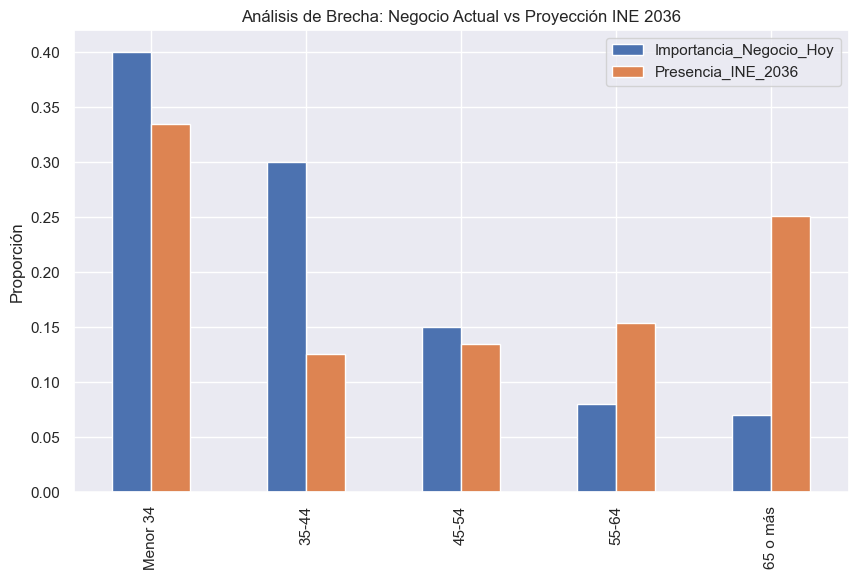

In [30]:
# 1. Calculamos la proporción de cada segmento en el INE para 2026 y 2036
# Basado en las columnas de edad de la imagen image_493359.png
segmentos_edad = ['Menor 34', '35-44', '45-54', '55-64', '65 o más']

# Proporción en 2036 (el futuro)
total_2036 = df.loc[df['Periodo'] == 2036, 'Total_pobl'].values[0]
prop_ine_2036 = (df.loc[df['Periodo'] == 2036, segmentos_edad] / total_2036).T
prop_ine_2036.columns = ['Presencia_INE_2036']

# 2. ACÁ DEBÉS PONER TUS DATOS DE CLUSTERS (Ejemplo hipotético)
# ¿Qué % de tus clientes actuales pertenecen a esos rangos?
datos_tu_negocio = {
    'Menor 34': 0.40,  # Supongamos que el 40% de tus clientes son jóvenes hoy
    '35-44': 0.30,
    '45-54': 0.15,
    '55-64': 0.08,
    '65 o más': 0.07}
df_gap = pd.DataFrame.from_dict(datos_tu_negocio, orient='index', columns=['Importancia_Negocio_Hoy'])

# 3. Unimos y calculamos la Brecha (Gap)
df_gap = df_gap.join(prop_ine_2036)
df_gap['Brecha'] = df_gap['Presencia_INE_2036'] - df_gap['Importancia_Negocio_Hoy']

# Visualización
df_gap[['Importancia_Negocio_Hoy', 'Presencia_INE_2036']].plot(kind='bar', figsize=(10,6))
plt.title('Análisis de Brecha: Negocio Actual vs Proyección INE 2036')
plt.ylabel('Proporción')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

# Conclusiones